# ITO 5221 - Module 2 (Solution)

In this module, we will discuss about Harris Corner Detection, Blob Detection, SIFT and LBP.

## Task 1 - Harris Corner Detector

### Study the effect on the output of the Harris detector by varying the parameters.

In [4]:
# Importing standard libraries
from skimage import data  # To input standard images
from matplotlib import pyplot as plt  # To plot images
from skimage.color import rgb2gray  # To convert RGB image to grayscale
from skimage.feature import corner_harris, corner_subpix, corner_peaks  # Library for Harris corner detection

<ipython-input-5-958a04d2e82f>:5: FutureWarning: The behavior of rgb2gray will change in scikit-image 0.19. Currently, rgb2gray allows 2D grayscale image to be passed as inputs and leaves them unmodified as outputs. Starting from version 0.19, 2D arrays will be treated as 1D images with 3 channels.
  gray_input_image = rgb2gray(input_image)


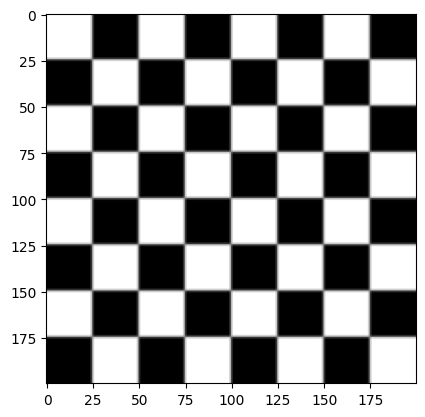

harris_response (200, 200)


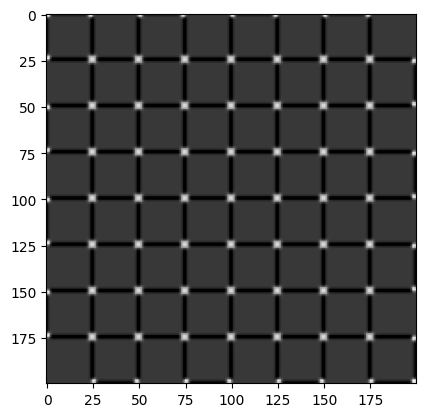

In [5]:
# Using standard image astronaut from skimage
input_image = data.checkerboard()

# TODO: get grayscale image of input image
gray_input_image = rgb2gray(input_image)
plt.imshow(gray_input_image, cmap="gray")
plt.show()

# TODO: apply "corner_harris(param1)" function to make Harris point detection
# param1: the grayscale image obtained above. Certainly, there are more than one parameters in "corner_harris()" function.
#         In this task, you do not need to consider these parameters, use their default configured values.
#         We will discuss different configurations of parameters in the following tasks.

harris_response = corner_harris(gray_input_image)  #Harris point detector
print('harris_response', harris_response.shape)
plt.imshow(harris_response, cmap='gray')
plt.show()

In [6]:
# function to Look for corners in the corner response image based on the parameters
# TODO: apply "corner_peaks(param1, param2, param3)"
# param1: the image obtained from "corner_harris()" function
# please use the following configuration of param2 and 3:
#         param2: min_distance=5
#         param3: threshold_rel=0.09
coordinates_peaks = corner_peaks(harris_response, min_distance=5, threshold_rel=0.09)
print('coordinates_peaks', coordinates_peaks.shape)
coordinates_peaks

coordinates_peaks (49, 2)


array([[ 24,  24],
       [124, 175],
       [125,  24],
       [125,  49],
       [125,  74],
       [125,  99],
       [125, 124],
       [125, 149],
       [149,  24],
       [149,  49],
       [149,  74],
       [100,  49],
       [100,  74],
       [100,  99],
       [100, 124],
       [100, 149],
       [100, 174],
       [100,  25],
       [149,  99],
       [149, 124],
       [174,  99],
       [174, 124],
       [174, 149],
       [174, 174],
       [175,  24],
       [174,  75],
       [175,  50],
       [149, 149],
       [149, 174],
       [ 25, 174],
       [ 49,  24],
       [ 49,  49],
       [ 49,  74],
       [ 49,  99],
       [ 25, 150],
       [ 49, 125],
       [ 49, 149],
       [ 49, 174],
       [ 25, 125],
       [ 24,  49],
       [ 24,  74],
       [ 24,  99],
       [ 75,  75],
       [ 75,  99],
       [ 75, 124],
       [ 75, 149],
       [ 75, 174],
       [ 75,  50],
       [ 75,  25]])

In [7]:
# function to determine the subpixel position of corners
# TODO: apply "corner_subpix(param1, param2, param3)"
# param1: the grayscale image
# param2: the corner detected image obtained from "corner_peaks()" function
# param3: size of window, please use "window_size=13"
coordinates_sub_pixels = corner_subpix(gray_input_image, coordinates_peaks, window_size=13)
print('coordinates_sub_pixels', coordinates_sub_pixels.shape)
coordinates_sub_pixels

coordinates_sub_pixels (49, 2)


array([[ 24.5,  24.5],
       [124.5, 174.5],
       [124.5,  24.5],
       [124.5,  49.5],
       [124.5,  74.5],
       [124.5,  99.5],
       [124.5, 124.5],
       [124.5, 149.5],
       [149.5,  24.5],
       [149.5,  49.5],
       [149.5,  74.5],
       [ 99.5,  49.5],
       [ 99.5,  74.5],
       [ 99.5,  99.5],
       [ 99.5, 124.5],
       [ 99.5, 149.5],
       [ 99.5, 174.5],
       [ 99.5,  24.5],
       [149.5,  99.5],
       [149.5, 124.5],
       [174.5,  99.5],
       [174.5, 124.5],
       [174.5, 149.5],
       [174.5, 174.5],
       [174.5,  24.5],
       [174.5,  74.5],
       [174.5,  49.5],
       [149.5, 149.5],
       [149.5, 174.5],
       [ 24.5, 174.5],
       [ 49.5,  24.5],
       [ 49.5,  49.5],
       [ 49.5,  74.5],
       [ 49.5,  99.5],
       [ 24.5, 149.5],
       [ 49.5, 124.5],
       [ 49.5, 149.5],
       [ 49.5, 174.5],
       [ 24.5, 124.5],
       [ 24.5,  49.5],
       [ 24.5,  74.5],
       [ 24.5,  99.5],
       [ 74.5,  74.5],
       [ 74

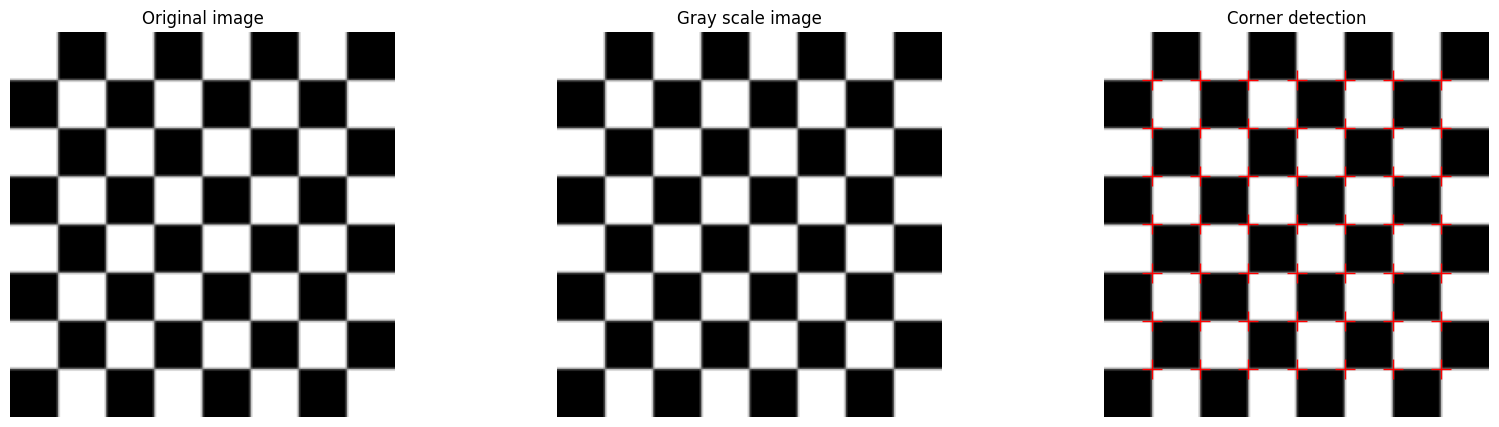

In [8]:
# TODO: to show the figures including 1. original image; 2. gray scale image; 3. image with the detected corners
fig, axarr = plt.subplots(1, 3, figsize=(20, 5))
# Let us display the original input image, gray scale image and the detected corner
axarr[0].imshow(input_image, cmap="gray")
axarr[0].set_title('Original image')
axarr[0].axis('off')
axarr[1].imshow(gray_input_image, cmap="gray")
axarr[1].set_title('Gray scale image')
axarr[1].axis('off')
axarr[2].imshow(gray_input_image, cmap="gray")
axarr[2].plot(coordinates_sub_pixels[:, 0], coordinates_sub_pixels[:, 1], '+r', markersize=15)
axarr[2].set_title('Corner detection')
axarr[2].axis('off')
plt.show()

### Altering parameters - Harris Response

`corner_harris()` computes the response image for the given image

Input arguments are -
- `method` - method to compute correlation matrix (can be 'k' or 'eps') # we are discussing the earlier only.
- `k` is senstivity factor whose value lies in range [0,0.2] to separate corners from edges
- `sigma` represent the weight of coorelation matrix

`sigma` - Standard deviation used for the Gaussian kernel,
which is used as weighting function for the auto-correlation matrix.

`k` - Sensitivity factor to separate corners from edges, typically in range $[0, 0.2]$.
Small values of `k` result in detection of sharp corners.
`k` is empirically calculated

Output - Response image

<ipython-input-9-1707fe84f381>:2: FutureWarning: The behavior of rgb2gray will change in scikit-image 0.19. Currently, rgb2gray allows 2D grayscale image to be passed as inputs and leaves them unmodified as outputs. Starting from version 0.19, 2D arrays will be treated as 1D images with 3 channels.
  gray_input_image = rgb2gray(input_image)


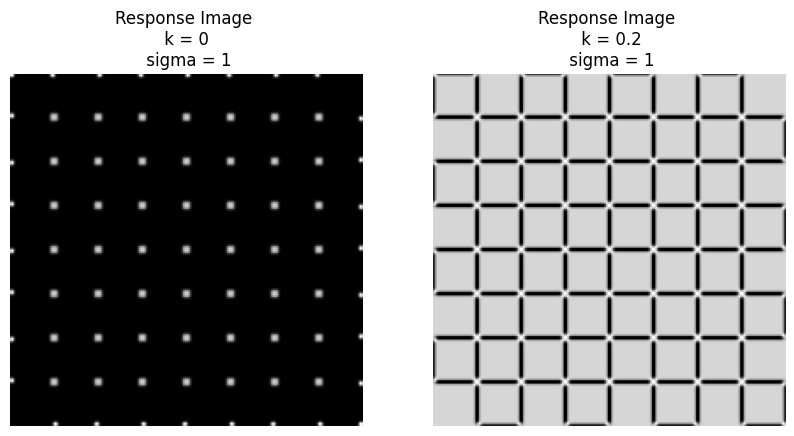

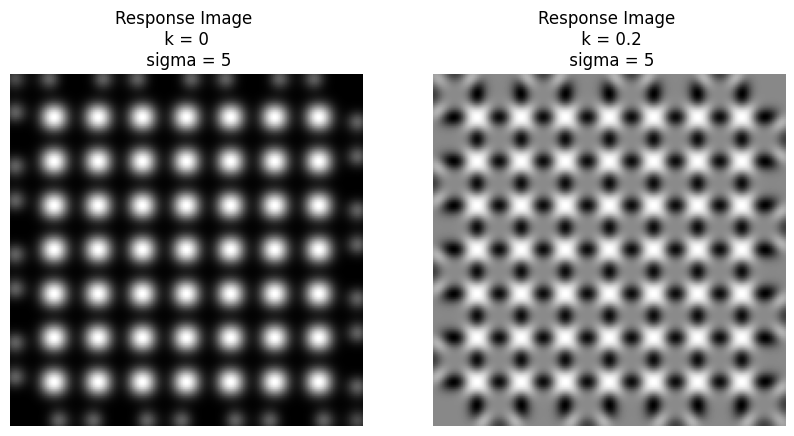

In [9]:
input_image = data.checkerboard()  # checkerboard
gray_input_image = rgb2gray(input_image)

fig, axarr = plt.subplots(1, 2, figsize=(10, 10))
axarr[0].imshow(corner_harris(gray_input_image, method='k', k=0, sigma=1), cmap='gray')  # Value of k is varied
axarr[0].set_title('Response Image \n k = 0 \n sigma = 1')
axarr[0].axis('off')
axarr[1].imshow(corner_harris(gray_input_image, method='k', k=0.2, sigma=1), cmap='gray')
axarr[1].set_title('Response Image \n k = 0.2\n sigma = 1')
axarr[1].axis('off')
plt.show()
fig, axarr1 = plt.subplots(1, 2, figsize=(10, 10))
axarr1[0].imshow(corner_harris(gray_input_image, method='k', k=0, sigma=5), cmap='gray')
axarr1[0].set_title('Response Image \n k = 0 \n sigma = 5')
axarr1[0].axis('off')
axarr1[1].imshow(corner_harris(gray_input_image, method='k', k=0.2, sigma=5), cmap='gray')
axarr1[1].set_title('Response Image \n k = 0.2\n sigma = 5')
axarr1[1].axis('off')
plt.show()

### Altering parameters - Coordinates of peaks

`corner_peaks()` returns the peak coordinates of the given response image
Input arguments are
- `image` - response image generated by `corner_harris()` and
- `min_distance` - to specify minimum allowed distance between peaks
- `threshold_rel` - minimum intensity of peaks
- `num_peaks` - maximum number of peaks (usually set to infinity to include all peaks returned)
- `indices` - to determine output type

Output -
Peak coordinate values of peaks numpy array if indices = true
Boolean array of image shape if indices = false

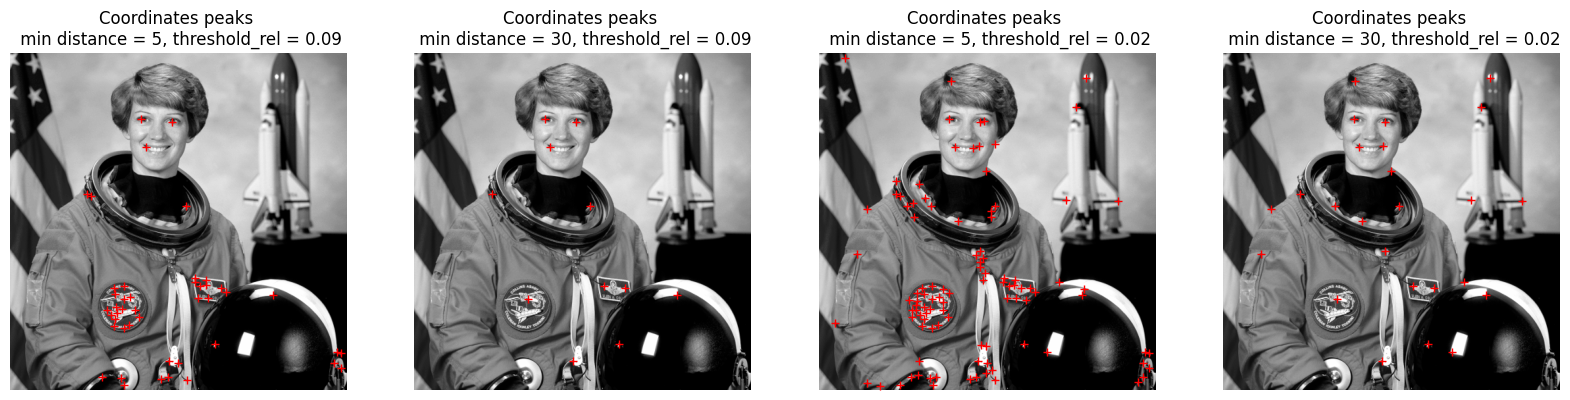

In [10]:
# Fixing parameters to generate response image
input_image = data.astronaut()  # astronaut
gray_input_image = rgb2gray(input_image)
harris_response = corner_harris(gray_input_image, method='k', k=0.2, sigma=1)

fig, axarr = plt.subplots(1, 4, figsize=(20, 20))
axarr[0].imshow(gray_input_image, cmap="gray")
coordinates_peaks = corner_peaks(harris_response, min_distance=5, threshold_rel=0.09, indices=True)
axarr[0].plot(coordinates_peaks[:, 1], coordinates_peaks[:, 0], color='red', marker='+', linestyle='None', markersize=6)
axarr[0].set_title('Coordinates peaks \n min distance = 5, threshold_rel = 0.09')
axarr[0].axis('off')

axarr[1].imshow(gray_input_image, cmap="gray")
# Notice with the large distance between the peaks
coordinates_peaks = corner_peaks(harris_response, min_distance=30, threshold_rel=0.09, indices=True)
axarr[1].plot(coordinates_peaks[:, 1], coordinates_peaks[:, 0], color='red', marker='+', linestyle='None', markersize=6)
axarr[1].set_title('Coordinates peaks \n min distance = 30, threshold_rel = 0.09')
axarr[1].axis('off')

axarr[2].imshow(gray_input_image, cmap="gray")
coordinates_peaks = corner_peaks(harris_response, min_distance=5, threshold_rel=0.02, indices=True)
axarr[2].plot(coordinates_peaks[:, 1], coordinates_peaks[:, 0], color='red', marker='+', linestyle='None', markersize=6)
axarr[2].set_title('Coordinates peaks \n min distance = 5, threshold_rel = 0.02')
axarr[2].axis('off')

axarr[3].imshow(gray_input_image, cmap="gray")
# Notice with the large distance between the peaks, alternate checkboard blocks are missed
coordinates_peaks = corner_peaks(harris_response, min_distance=30, threshold_rel=0.02, indices=True)
axarr[3].plot(coordinates_peaks[:, 1], coordinates_peaks[:, 0], color='red', marker='+', linestyle='None', markersize=6)
axarr[3].set_title('Coordinates peaks \n min distance = 30, threshold_rel = 0.02')
axarr[3].axis('off')
plt.show()

## Task 2 - Blob detection

In [7]:
# import libraries
from math import sqrt
from skimage import data
from skimage.feature import blob_dog, blob_log  # DoG and LoG
from skimage.color import rgb2gray

import matplotlib.pyplot as plt

# input image
image = data.hubble_deep_field()[200:700, 200:700]
image_gray = rgb2gray(image)

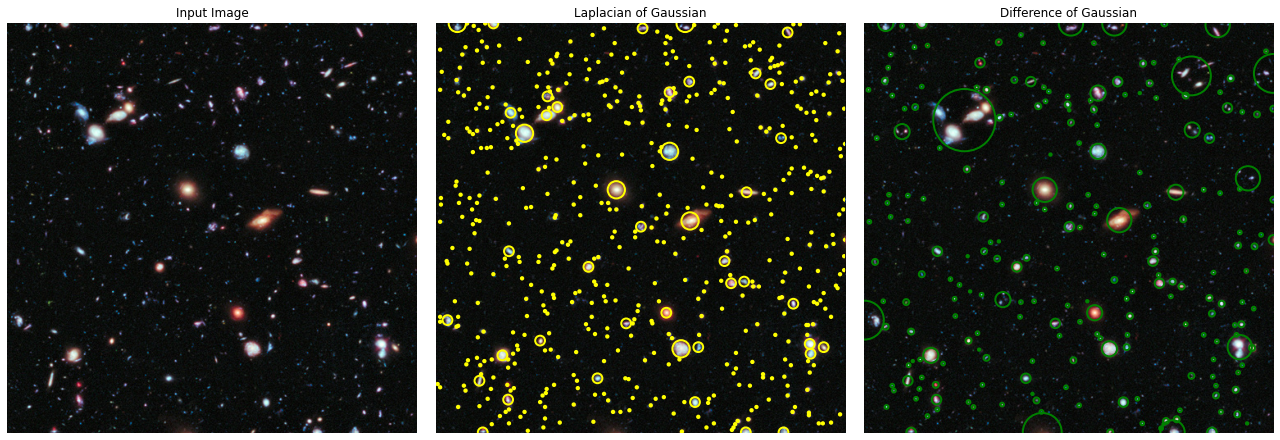

In [8]:
# Syntax - blob_log(image, max_sigma=..., num_sigma=..., threshold=...)
# The return value is Array of [y, x, sigma], you can get radius by
# radius = sigma * sqrt(2)

# TODO - Apply Laplacian of Gaussian (LoG) to the input image
# use the arguments: max_sigma=30, num_sigma=10, threshold=.1
blobs_log = blob_log(image_gray, max_sigma=30, num_sigma=10, threshold=.1)

# Syntax - blob_dog(image, max_sigma=..., threshold=...)
# TODO - Apply Difference of Gaussian (LoG) to the input image
# use the arguments: max_sigma=30, threshold=.1
blobs_dog = blob_dog(image_gray, max_sigma=30, threshold=.1)

# TODO - Display the original image, LoG result and DoG result
# hint: you can use axes[...].add_patch(plt.Circle((x, y), radius, ...) to add circles
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex="all", sharey="all")

axes[0].set_title("Input Image")
axes[0].imshow(image)
axes[0].set_axis_off()

axes[1].set_title("Laplacian of Gaussian")
axes[1].imshow(image)
axes[1].set_axis_off()
for blob in blobs_log:
    y, x, sigma = blob
    axes[1].add_patch(plt.Circle((x, y), sigma * sqrt(2), color="yellow", linewidth=2, fill=False))

axes[2].set_title("Difference of Gaussian")
axes[2].imshow(image)
axes[2].set_axis_off()
for blob in blobs_dog:
    y, x, sigma = blob
    axes[2].add_patch(plt.Circle((x, y), sigma * sqrt(2), color="green", linewidth=2, fill=False))

plt.tight_layout()
plt.show()

## Reference

Blob Detection — skimage v0.19.2 docs. (2022). Retrieved 14 March 2022, from https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_blob.html

## Task 3 - SIFT and Matching

In [25]:
# install opencv (run in console). Run anyone of below.
# conda install opencv -c conda-forge
# pip install -U opencv-python

In [ ]:
# import libraries
from skimage.data import hubble_deep_field  # input image
import matplotlib.pyplot as plt
import cv2  # SIFT
from typing import List

# input images
input_img = hubble_deep_field()
img1 = input_img[0:300, 0:300]
img2 = input_img[50:350, 150:450]

# visualize 2 input images for matching
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.axis("off")
plt.show()

In [27]:
# In this task, we use OpenCV to demonstrate SIFT and interest point matching
sift: cv2.SIFT = cv2.SIFT_create()

In [28]:
# TODO - Detect key points by SIFT for 2 input images.
# Use `cv2.SIFT` object we created, invoke method `sift.detectAndCompute(image, mask)`. Set mask=None.
# Return value: (key_points, descriptors)
key_points_1, descriptors_1 = sift.detectAndCompute(img1, None)
key_points_2, descriptors_2 = sift.detectAndCompute(img2, None)

In [42]:
# TODO - Match the key points with SIFT descriptors
# Here we use K-Nearest-Neighbour (KNN) algorithm for matching.
# In opencv, you need create a `cv2.BFMatcher` object,
# then use `matcher.knnMatch(des1, des2, k)` to match
# set k=2
matcher: cv2.BFMatcher = cv2.BFMatcher()
matches: List[List[cv2.DMatch]] = matcher.knnMatch(descriptors_1, descriptors_2, k=2)

In [43]:
threshold = 0.8  # try to change it

# TODO - Filter the matches by ratio test.
# if `d1` is the distance of closest neighbour, `d2` is the distance of 2nd closest neighbour
# then choose the nearest neighbour which satisfies `d1 < threshold * d2`
def filter_good_match(neighbours: List[cv2.DMatch]) -> bool:
    return neighbours[0].distance < threshold * neighbours[1].distance

matches = [*map(lambda neighbours: neighbours[:1], filter(filter_good_match, matches))]

In [44]:
# TODO - Generate the visualization
# Use `cv2.drawMatchesKnn()`, function signature:
# drawMatchesKnn(img1, keypoints1, img2, keypoints2, matches1to2, outImg, matchColor=None, singlePointColor=None, matchesMask=None, flags=None)
match_visualization = cv2.drawMatchesKnn(img1, key_points_1, img2, key_points_2, matches, None,
                                         flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

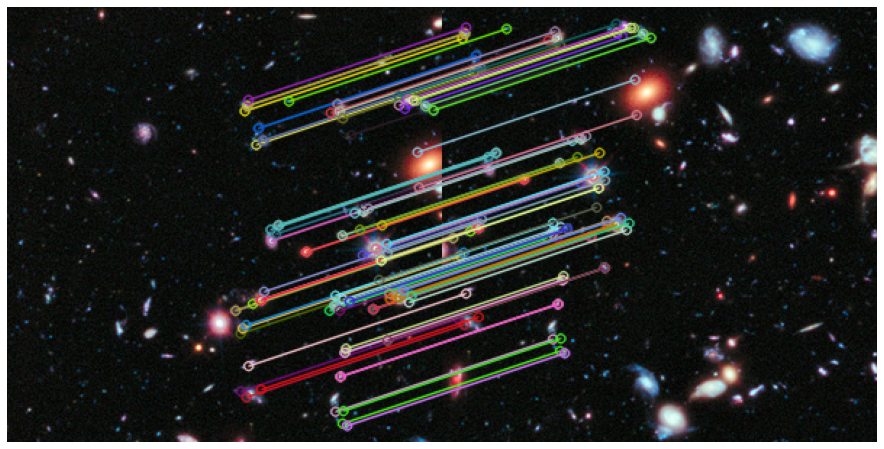

In [45]:
# TODO - Display the visualization
plt.figure(figsize=(16, 8))
plt.imshow(match_visualization)
plt.axis("off")
plt.show()

## Reference

- OpenCV: Feature Matching. (2022). Retrieved 18 March 2022, from https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
- OpenCV: Introduction to SIFT (Scale-Invariant Feature Transform). (2022). Retrieved 18 March 2022, from https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html

## Task 4 - Local binary pattern

Gray scale and rotation invariant LBP (Local Binary Patterns). LBP is an invariant descriptor that can be used for texture classification.

```python
skimage.feature.local_binary_pattern(image, P, R, method='default')
```
```
Parameters:
    image:(N, M) array Grayscale image.
    P: int, Number of circularly symmetric neighbour set points (quantization of the angular space).
    R: float, Radius of circle (spatial resolution of the operator).
    method: {‘default’, ‘ror’, ‘uniform’, ‘var’} Method to determine the local binary pattern.
        ‘default’: original local binary pattern which is gray scale but not rotation invariant. 
        ‘ror’: extension of default implementation which is gray scale and rotation invariant.
        ‘uniform’: improved rotation invariance with uniform patterns and finer quantization of the angular space which is gray scale and rotation invariant.
        ‘nri_uniform’: non rotation-invariant uniform patterns variant which is only gray scale invariant. https://link.springer.com/content/pdf/10.1007/978-3-540-24670-1_36.pdf
        ‘var’: rotation invariant variance measures of the contrast of local image texture which is rotation but not gray scale invariant.

Returns:
    output(N, M) array LBP image.
```

Setting the variables for LBP The effectiveness of the LBP feature descriptor is dependent on the parameters, specially, the search space defining the neighborhood. Change parameters and observe the changes in the histgorams in the later part of the problem.

In [12]:
from skimage import data # To input standard images
from skimage.transform import rotate
from matplotlib import pyplot as plt # To plot images
from skimage.color import rgb2gray # To convery RGB image to grayscale
from skimage.feature import local_binary_pattern # Library for local_binary_pattern
import numpy as np 

For Histogram Intersection Kernel-

An example of instersection/overlap between two histograms

![alt text](https://blog.datadive.net/wp-content/uploads/2016/02/intersect.png)

Define a function match(), which takes into input image, image list and distance metric function to use from above for histograms.

In [13]:
# TODO - Define a function for KL divergence
def kullback_leibler_divergence(hist1, hist2): 
    hist1 = hist1.ravel()
    hist2 = hist2.ravel()
    return np.sum(np.where(hist1 != 0, hist1 * np.log(hist1 / hist2), 0))

def histogram_intersection_distance(hist1, hist2, widthHist): # Compute Histogram Intersection based distance
    hist1 = hist1.ravel()
    hist2 = hist2.ravel()
    sumVal = 0
    for i in range(widthHist):
        sumVal += min(hist1[i], hist2[i])
    return sumVal 

def hist(ax, lbp): # Function to compute histogram of 'lbp' features. Histogram is plotted on ax axis.
    n_bins = int(lbp.max() + 1)
    return ax.hist(lbp.ravel(), density=True, bins=n_bins, range=(0, n_bins),
                   facecolor='0.5')

def match(refs, img, distanceMetric): #Match two histograms
    threshold_KL = 10.0 #choose a high number
    threshold_HistIntersection = 0.0 
   
    lbp = local_binary_pattern(img, n_points, radius, METHOD) #compute LBP map
    n_bins = int(lbp.max() + 1)
#     np.histogram() also returns bin edges - not required
    hist, _ = np.histogram(lbp, density=True, bins=n_bins, range=(0, n_bins)) #compute histogram from the LBP image map
    
    for name, ref in refs.items():
        ref_hist, _ = np.histogram(ref, density=True, bins=n_bins,
                                   range=(0, n_bins))
        if distanceMetric == 'histogram_intersection_distance':
            score = globals()[distanceMetric](hist,ref_hist,n_bins) #use global to call function from global symbol table
            print("Distance Metric: ", distanceMetric, " Score: ", score)
       
            if score > threshold_HistIntersection: #comparison if we have found the best match
                threshold_HistIntersection = score
                labels = name    
    
        if distanceMetric == 'kullback_leibler_divergence':
            score = globals()[distanceMetric](hist,ref_hist)
            print("Distance Metric: ", distanceMetric, " Score: ", score)
            if score < threshold_KL:  #comparison if we have found the best match
                threshold_KL = score
                labels = name
          
    return labels

Input images into a list compute the histogram similarity

Use data.bricks() data.grass() and data.gravel()

Display the LBP histogram and effect on different parameters

Rotated images matched against references using LBP:

Finding match for brick image
Distance Metric:  kullback_leibler_divergence  Score:  0.0
Distance Metric:  kullback_leibler_divergence  Score:  0.1711960782675489
Distance Metric:  kullback_leibler_divergence  Score:  0.1029006753901831
original: brick, match result:  brick
Distance Metric:  histogram_intersection_distance  Score:  1.0
Distance Metric:  histogram_intersection_distance  Score:  0.8477783203125
Distance Metric:  histogram_intersection_distance  Score:  0.841522216796875
original: brick, match result:  brick

Finding match for rotated brick image by 30 deg
Distance Metric:  kullback_leibler_divergence  Score:  0.08977120278763706
Distance Metric:  kullback_leibler_divergence  Score:  0.2770196637717362
Distance Metric:  kullback_leibler_divergence  Score:  0.20890405436053705
original: brick, rotated: 30deg, match result:  brick

Finding match for rotated brick image by 70 deg
Distance Metric:  kullback_leibler_diverge

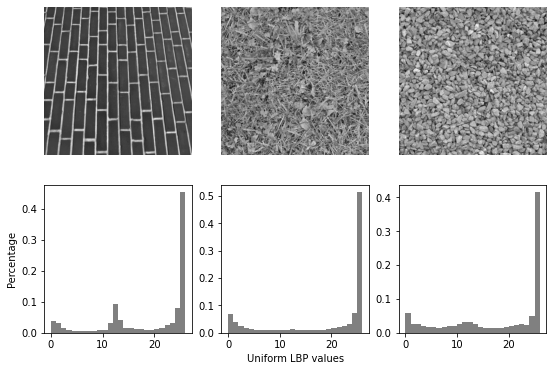

In [14]:
# settings for LBP
radius = 3
n_points = 8 * radius
METHOD = 'uniform' 
#input images from data

brick = data.brick()
grass = data.grass()
gravel = data.gravel()

refs = {
    'brick': local_binary_pattern(brick, n_points, radius, METHOD),
    'grass': local_binary_pattern(grass, n_points, radius, METHOD),
    'gravel': local_binary_pattern(gravel, n_points, radius, METHOD)
}

# classify rotated textures
print('Rotated images matched against references using LBP:')

print('\nFinding match for brick image')
print('original: brick, match result: ',
      match(refs, brick,'kullback_leibler_divergence'))

print('original: brick, match result: ',
      match(refs, brick,'histogram_intersection_distance'))

print('\nFinding match for rotated brick image by 30 deg')
print('original: brick, rotated: 30deg, match result: ',
      match(refs, rotate(brick, angle=30, resize=False),'kullback_leibler_divergence')) #call the match() to compare the histograms of two images

print('\nFinding match for rotated brick image by 70 deg')
print('original: brick, rotated: 70deg, match result: ',
      match(refs, rotate(brick, angle=70, resize=False),'kullback_leibler_divergence'))

print('\nFinding match for rotated grass image by 145 deg')
print('original: grass, rotated: 145deg, match result: ',
      match(refs, rotate(grass, angle=145, resize=False),'kullback_leibler_divergence'))

# plot histograms of LBP of textures
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(nrows=2, ncols=3,
                                                       figsize=(9, 6))
plt.gray()

ax1.imshow(brick)
ax1.axis('off')
hist(ax4, refs['brick'])
ax4.set_ylabel('Percentage')

ax2.imshow(grass)
ax2.axis('off')
hist(ax5, refs['grass'])
ax5.set_xlabel('Uniform LBP values')

ax3.imshow(gravel)
ax3.axis('off')
hist(ax6, refs['gravel'])

plt.show()
